# **Reliance Industries: 15-Year Risk & Return Analysis**

## 1. Executive Summary

This project presents a quantitative analysis of the historical **risk and return characteristics of Reliance Industries** using approximately 15 years of monthly market data.

The objective is to move beyond a simple examination of stock-price movements and evaluate the asset through a structured financial framework covering **return, compounding, volatility, drawdown, market co-movement, and systematic risk**.

The analysis uses **NIFTY 50** as the market benchmark to place Reliance's historical performance in the context of the broader Indian equity market.

### Analytical Framework

**Historical Prices → Returns → Annual & Compounded Performance → Volatility & Drawdown → Return Distribution → Market Relationship → Beta**

### Key Objective

> **How has Reliance Industries performed historically, what level of return variability and drawdown risk has accompanied that performance, and how closely has its return behavior been associated with the broader Indian equity market?**

This is a **historical, descriptive** study. Results characterize observed behavior during the sample period and are **not** a forecast of future returns.

### Tools & Technologies

Python · pandas · NumPy · Matplotlib · yfinance (data acquisition)

### Project Structure

| Section | Focus |
|---|---|
| 2. Objective & Research Questions | Questions addressed by the analysis |
| 3. Data & Methodology | Dataset, frequency, methodology, assumptions |
| 4. Imports & Configuration | Libraries and analysis constants |
| 5. Data Acquisition | Loading (or downloading) raw data |
| 6. Data Preparation & Quality Checks | Validation and preprocessing |
| 7. Historical Price Analysis | Long-term price behavior |
| 8. Return Analysis | Monthly return characteristics |
| 9. Annual Return Analysis | Calendar-year performance |
| 10. Cumulative Performance & CAGR | Compounded long-term performance |
| 11. Volatility & Maximum Drawdown | Historical return variability and worst peak-to-trough loss |
| 12. Distribution of Returns | Shape of monthly outcomes (skew, kurtosis) |
| 13. Market Benchmark: NIFTY 50 | Market-relative analysis |
| 14. Beta & Correlation Analysis | Systematic risk and co-movement |
| 15. Key Findings | Consolidated results |
| 16. Limitations | Explicit scope and assumptions |
| 17. Conclusion | Overall interpretation |


## 2. Objective & Research Questions

### Objective

Evaluate the historical **return and risk profile of Reliance Industries** using monthly market data, and examine its relationship with the broader Indian equity market. The analysis separates **absolute performance** from **risk and market exposure** — a stock's return is only one dimension of its investment characteristics.

### Research Questions

1. **Return Performance** — How have Reliance's monthly, annual, and compounded (CAGR) returns behaved?
2. **Risk & Volatility** — How variable have returns been, and what is the annualized volatility?
3. **Drawdown Risk** — What is the worst peak-to-trough loss an investor would have experienced?
4. **Return Distribution** — What does the shape of the monthly return distribution reveal?
5. **Market Relationship** — How strongly have Reliance's returns moved with the NIFTY 50?
6. **Systematic Risk** — What does beta indicate about sensitivity to broad market movements?

| Perspective | Primary Measures | Question |
|---|---|---|
| **Performance** | Return, Annual Return, CAGR, Cumulative Return | How did the stock perform? |
| **Total Risk** | Volatility, Max Drawdown, Return Distribution | How variable were the returns, and how bad was the worst loss? |
| **Market Exposure** | Covariance, Correlation, Beta | How did the stock behave relative to the market? |


## 3. Data & Methodology

### 3.1 Data Overview

- **Reliance Industries (RELIANCE.NS)** — the primary security.
- **NIFTY 50 (^NSEI)** — the market benchmark.

Both series contain OHLCV fields (Open, High, Low, Close, Volume) at **monthly** frequency.

### 3.2 Price-to-Return Transformation

$$
R_t = \frac{P_t}{P_{t-1}} - 1
$$

### 3.3 Adjustment for Corporate Actions

Prices are downloaded with `auto_adjust=True`, which adjusts historical prices for corporate actions such as stock splits and bonus issues. Reliance issued a 1:1 bonus share with an ex-date/record date of 28 October 2024. NSE specifies an adjustment factor of 2 for this corporate action.

The adjusted Reliance series is checked in Section 6: the September-to-October 2024 adjusted price change is approximately −2.99%, with no artificial ~50% price cliff. An unadjusted series would reflect the mechanical per-share price reduction associated with the 1:1 bonus rather than an equivalent economic loss to shareholders.

**Cannot verify from the provided data:** whether dividend reinvestment is included in the adjustment. This is noted as a limitation in Section 16.

### 3.4 Scope

The analysis is **descriptive and historical**. It does not incorporate transaction costs, taxes, a risk-free rate, or an investment strategy, and does not constitute investment advice.


## 4. Imports & Configuration

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

In [2]:
# --- Analysis constants (defined once, referenced everywhere below) ---
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

RELIANCE_CSV = "../data/raw/Reliance_15_Year_Monthly.csv"
NIFTY_CSV = "../data/raw/Nifty_15_Year_Monthly.csv"

TICKER_STOCK = "RELIANCE.NS"
TICKER_BENCHMARK = "^NSEI"
START_DATE, END_DATE, INTERVAL = "2011-01-01", "2025-12-31", "1mo"
PERIODS_PER_YEAR = 12  # monthly data -> 12 periods/year for annualization

plt.rcParams.update({
    "font.family": "DejaVu Sans",   # portable default; avoids missing-font fallback warnings
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "figure.figsize": (11, 5),
})

## 5. Data Acquisition

Loads the committed CSVs if present; otherwise downloads fresh data via `yfinance` using **identical acquisition parameters for both tickers** (same explicit date range, same `auto_adjust` flag) so the two series are guaranteed to be adjusted and aligned consistently.

In [3]:
if not (os.path.exists(RELIANCE_CSV) and os.path.exists(NIFTY_CSV)):
    import yfinance as yf
    reliance_raw = yf.download(TICKER_STOCK, start=START_DATE, end=END_DATE,
                                interval=INTERVAL, auto_adjust=True)
    nifty_raw = yf.download(TICKER_BENCHMARK, start=START_DATE, end=END_DATE,
                             interval=INTERVAL, auto_adjust=True)
    reliance_raw.to_csv(RELIANCE_CSV)
    nifty_raw.to_csv(NIFTY_CSV)


df = pd.read_csv(RELIANCE_CSV, skiprows=[1, 2])
nifty = pd.read_csv(NIFTY_CSV, skiprows=[1, 2])

# Rename the first column from "Price" to "Date"
df.rename(columns={"Price": "Date"}, inplace=True)
nifty.rename(columns={"Price": "Date"}, inplace=True)
df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2011-01-01,187.361694,222.437231,183.835789,217.056675,447426553
1,2011-02-01,196.522873,205.724847,180.391384,188.543745,539510608
2,2011-03-01,213.816101,215.018581,196.471953,198.448899,431843698
3,2011-04-01,200.497162,217.240075,197.694786,213.805895,281688030
4,2011-05-01,195.786377,202.975256,184.781941,202.378744,314277568


## 6. Data Preparation & Quality Checks

Financial return calculations depend on correct ordering and integrity of observations:

$$R_t = \frac{P_t}{P_{t-1}} - 1$$

requires $P_t$ to be correctly paired with the immediately preceding $P_{t-1}$. The checks below confirm the dataset is fit for that.

In [4]:
df.info()
print()
print("Missing values per column:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    180 non-null    str    
 1   Close   180 non-null    float64
 2   High    180 non-null    float64
 3   Low     180 non-null    float64
 4   Open    180 non-null    float64
 5   Volume  180 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 10.3 KB

Missing values per column:
 Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [5]:
# Explicit date format (both dates are always day=1, so format is unambiguous either way,
# but stating it explicitly removes reliance on pandas' format inference)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# --- Validation assertions: fail loudly rather than silently propagate bad data ---
assert df["Date"].is_monotonic_increasing, "Dates are not sorted"
assert df["Date"].duplicated().sum() == 0, "Duplicate dates found"
assert not df[["Open", "High", "Low", "Close"]].isnull().any().any(), "Missing prices found"
assert (df["High"] >= df["Low"]).all(), "High < Low on at least one row"

print(f"Rows: {len(df)}  |  Range: {df['Date'].min().date()} to {df['Date'].max().date()}")

Rows: 180  |  Range: 2011-01-01 to 2025-12-01


**Verifying the bonus-share adjustment.** Reliance issued a 1:1 bonus share (record date 28 Oct 2024). On
correctly adjusted data this should **not** appear as a price cliff — the code below confirms the September→October
2024 change is a normal monthly move, not a ~50% drop.

In [6]:
around_bonus = df[df["Date"].between("2024-08-01", "2024-12-01")][["Date", "Close"]]
print(around_bonus.to_string(index=False))
sep_to_oct = around_bonus.set_index("Date")["Close"].pct_change().iloc[-2]
print(f"\nSep -> Oct 2024 change: {sep_to_oct:+.2%}  (a spurious ~-50% here would indicate unadjusted data)")

      Date       Close
2024-08-01 1496.699585
2024-09-01 1463.932495
2024-10-01 1320.645020
2024-11-01 1281.136108
2024-12-01 1205.043213

Sep -> Oct 2024 change: -2.99%  (a spurious ~-50% here would indicate unadjusted data)


## 7. Historical Price Analysis

Price levels alone don't measure investment performance — a move from ₹100 to ₹500 and ₹1,000 to ₹1,400 mean
different things unless expressed as a percentage change. The chart below is context for the return analysis
that follows.

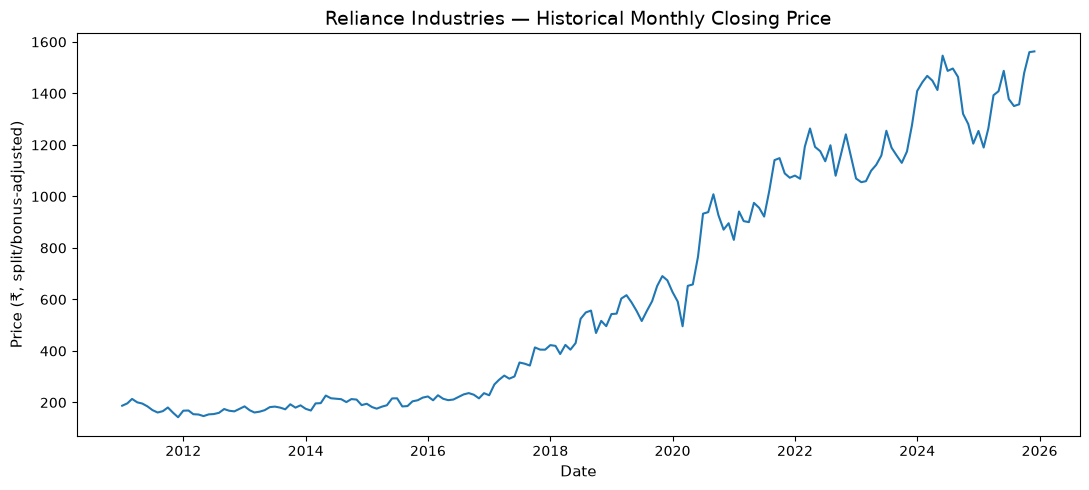

In [7]:
plt.figure()
plt.plot(df["Date"], df["Close"])
plt.title("Reliance Industries — Historical Monthly Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (₹, split/bonus-adjusted)")
plt.tight_layout()
plt.savefig("../figures/01_price_history.png", dpi=150)
plt.show()

## 8. Return Analysis

$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

Returns normalize price changes into comparable percentage terms, and are the input to every risk measure that follows.

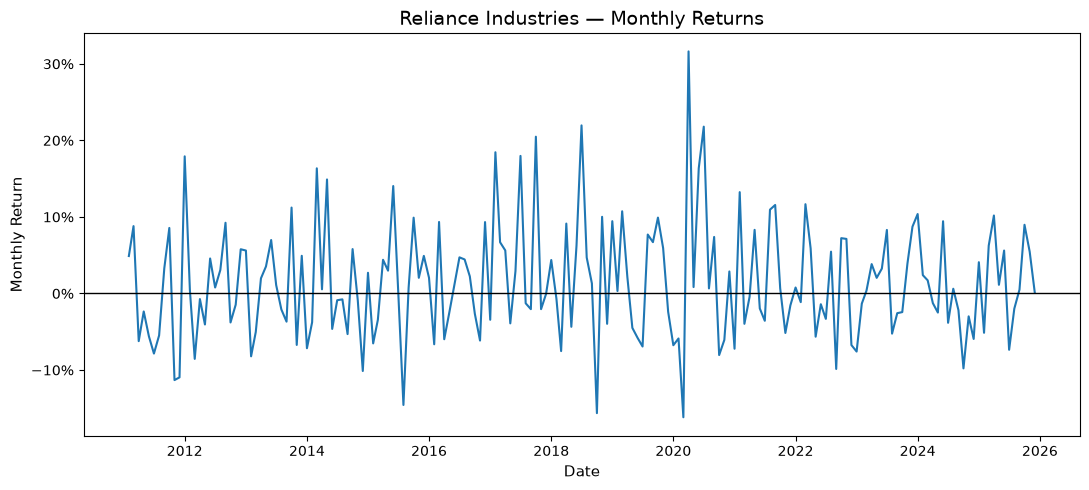

In [8]:
df["Monthly_Return"] = df["Close"].pct_change()

plt.figure()
plt.plot(df["Date"], df["Monthly_Return"])
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.axhline(0, linewidth=1, color="black")
plt.title("Reliance Industries — Monthly Returns")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.tight_layout()
plt.savefig("../figures/02_monthly_returns.png", dpi=150)
plt.show()

In [9]:
mean_return = df["Monthly_Return"].mean()
monthly_vol = df["Monthly_Return"].std()          # ddof=1, sample std
return_skew = df["Monthly_Return"].skew()
return_kurtosis = df["Monthly_Return"].kurtosis()  # excess kurtosis (0 = normal)

best_month = df.loc[df["Monthly_Return"].idxmax()]
worst_month = df.loc[df["Monthly_Return"].idxmin()]

print(f"Average monthly return : {mean_return:.2%}")
print(f"Monthly volatility     : {monthly_vol:.2%}")
print(f"Skewness               : {return_skew:.2f}")
print(f"Excess kurtosis        : {return_kurtosis:.2f}")
print(f"Best month  : {best_month['Date'].date()}  ({best_month['Monthly_Return']:+.2%})")
print(f"Worst month : {worst_month['Date'].date()}  ({worst_month['Monthly_Return']:+.2%})")

Average monthly return : 1.47%
Monthly volatility     : 7.56%
Skewness               : 0.67
Excess kurtosis        : 1.10
Best month  : 2020-04-01  (+31.63%)
Worst month : 2020-03-01  (-16.17%)


**Note on the average monthly return.** The arithmetic mean above is *not* the compounded growth rate an
investor actually realized — see Section 10 (CAGR) for that distinction. Positive skew and excess kurtosis > 0
indicate the return distribution has a longer right tail and fatter tails than a normal distribution (visualized
in Section 12).

## 9. Annual Return Analysis

Annual return is the **compounded** product of monthly growth factors, not a simple sum:

$$R_{annual} = \prod_{t=1}^{12}(1+R_t) - 1$$

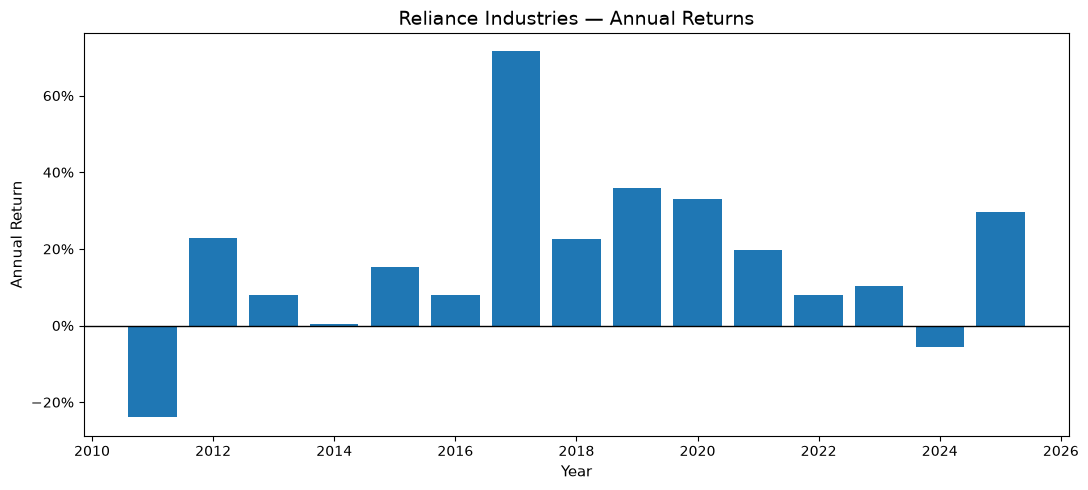

,Year,Annual_Return,Months
0,2011,-0.239262,12
1,2012,0.227566,12
2,2013,0.079148,12
3,2014,0.005298,12
4,2015,0.152873,12
5,2016,0.078836,12
6,2017,0.715395,12
7,2018,0.225498,12
8,2019,0.358429,12
9,2020,0.329067,12


In [10]:
df["Year"] = df["Date"].dt.year
annual_returns = df.groupby("Year")["Monthly_Return"].apply(lambda x: (1 + x).prod() - 1)
months_per_year = df.groupby("Year").size()

annual_df = annual_returns.reset_index()
annual_df.columns = ["Year", "Annual_Return"]
annual_df["Months"] = months_per_year.values

plt.figure()
plt.bar(annual_df["Year"], annual_df["Annual_Return"], color="#1f77b4")
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.axhline(0, linewidth=1, color="black")
plt.title("Reliance Industries — Annual Returns")
plt.xlabel("Year")
plt.ylabel("Annual Return")
plt.tight_layout()
plt.savefig("../figures/03_annual_returns.png", dpi=150)
plt.show()

annual_df

## 10. Cumulative Performance & CAGR

**Cumulative return** captures compounded growth over the full period:

$$CR_t = \prod_{i=1}^{t}(1+R_i) - 1$$

**CAGR** (Compound Annual Growth Rate) restates that as a single annualized rate — the number that answers
"what annual return, compounded every year, would have produced this same total growth?":

$$CAGR = \left(\frac{P_{end}}{P_{start}}\right)^{\frac{1}{n_{years}}} - 1$$

This is different from the arithmetic average monthly return in Section 8 — CAGR accounts for compounding and
is the figure comparable to a bank's annual interest rate.

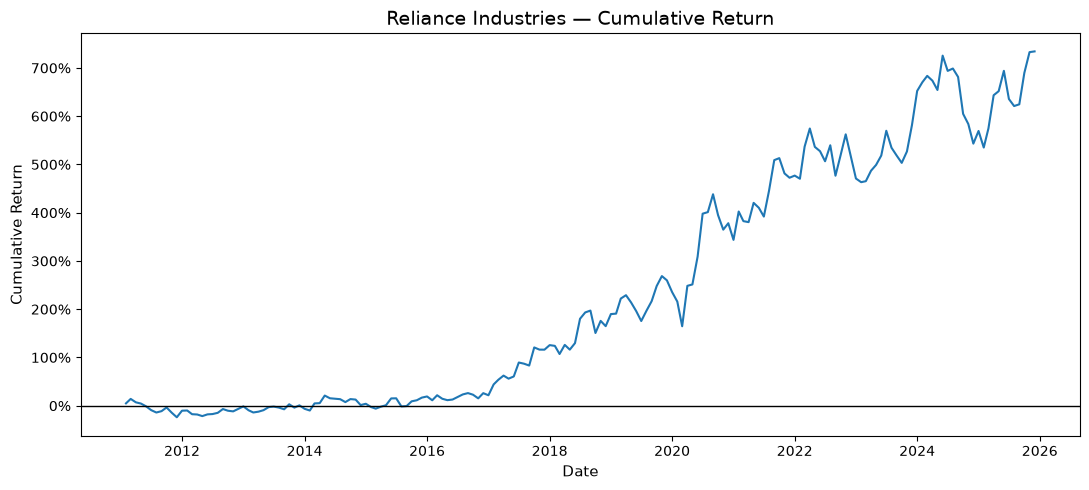

In [11]:
df["Cumulative_Return"] = (1 + df["Monthly_Return"]).cumprod() - 1

plt.figure()
plt.plot(df["Date"], df["Cumulative_Return"])
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.axhline(0, linewidth=1, color="black")
plt.title("Reliance Industries — Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.tight_layout()
plt.savefig("../figures/04_cumulative_return.png", dpi=150)
plt.show()

In [12]:
n_years = (len(df) - 1) / PERIODS_PER_YEAR
cagr = (df["Close"].iloc[-1] / df["Close"].iloc[0]) ** (1 / n_years) - 1
cumulative_return_total = df["Cumulative_Return"].iloc[-1]

print(f"Observation period      : {n_years:.2f} years")
print(f"Total cumulative return : {cumulative_return_total:.2%}")
print(f"CAGR                    : {cagr:.2%}")
print(f"(Naive x12 annualization of the mean monthly return would suggest {mean_return*12:.2%} — "
      f"compare this to CAGR above to see why compounding matters.)")

Observation period      : 14.92 years
Total cumulative return : 734.31%
CAGR                    : 15.28%
(Naive x12 annualization of the mean monthly return would suggest 17.59% — compare this to CAGR above to see why compounding matters.)


## 11. Volatility & Maximum Drawdown

**Volatility** (standard deviation of returns) treats upside and downside symmetrically and is scaled to an
annual figure using the square-root-of-time convention:

$$\sigma_{annual} = \sigma_{monthly}\sqrt{12}$$

**Maximum drawdown** answers a different, more intuitive question: *what is the largest peak-to-trough decline
an investor would have experienced?* It is asymmetric by construction and is a standard companion metric to
volatility for any project titled "risk analysis."

$$Drawdown_t = \frac{Wealth_t}{\max_{i \le t}(Wealth_i)} - 1 \qquad MaxDD = \min_t(Drawdown_t)$$

In [13]:
annualized_vol = monthly_vol * np.sqrt(PERIODS_PER_YEAR)

print(f"Monthly volatility     : {monthly_vol:.2%}")
print(f"Annualized volatility  : {annualized_vol:.2%}")
print("(Annualization assumes i.i.d. monthly returns — a simplifying assumption, not a tested property of this series.)")

Monthly volatility     : 7.56%
Annualized volatility  : 26.19%
(Annualization assumes i.i.d. monthly returns — a simplifying assumption, not a tested property of this series.)


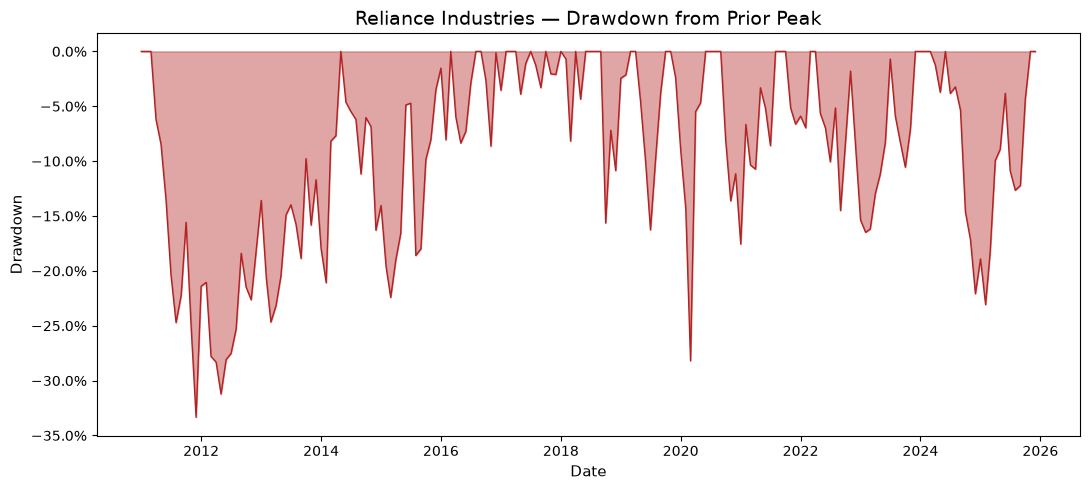

Maximum drawdown : -33.34%  (trough: 2011-12-01)


In [14]:
wealth_index = (1 + df["Monthly_Return"].fillna(0)).cumprod()
running_max = wealth_index.cummax()
drawdown = wealth_index / running_max - 1

max_drawdown = drawdown.min()
trough_date = df.loc[drawdown.idxmin(), "Date"]

plt.figure()
plt.fill_between(df["Date"], drawdown, 0, color="firebrick", alpha=0.4)
plt.plot(df["Date"], drawdown, color="firebrick", linewidth=1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.title("Reliance Industries — Drawdown from Prior Peak")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.savefig("../figures/05_drawdown.png", dpi=150)
plt.show()

print(f"Maximum drawdown : {max_drawdown:.2%}  (trough: {trough_date.date()})")

## 12. Distribution of Returns

The histogram shows the empirical shape of monthly returns. The skewness and kurtosis computed in Section 8 are
annotated below rather than assumed — empirical financial returns frequently deviate from normality, and this
lets the chart show *how*, not just assert that it might.

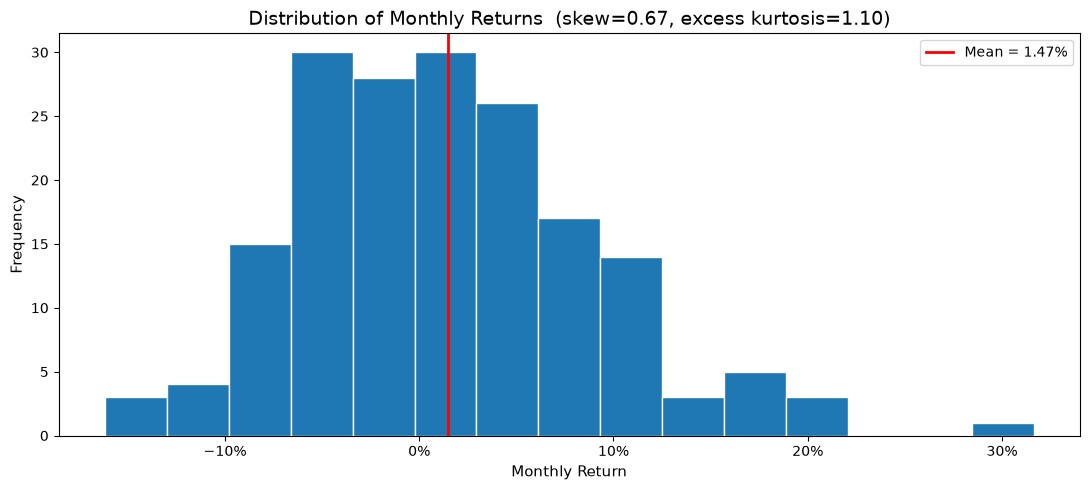

In [15]:
plt.figure()
plt.hist(df["Monthly_Return"].dropna(), bins=15, edgecolor="white")
plt.axvline(mean_return, color="red", linewidth=2, label=f"Mean = {mean_return:.2%}")
plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.title(f"Distribution of Monthly Returns  (skew={return_skew:.2f}, excess kurtosis={return_kurtosis:.2f})")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/06_return_distribution.png", dpi=150)
plt.show()

## 13. Market Benchmark: NIFTY 50

A benchmark provides a reference point for evaluating whether Reliance's return behavior reflects broad market
movements (systematic factors) or company-specific ones (idiosyncratic factors). NIFTY 50 serves that role here.

In [16]:
nifty["Date"] = pd.to_datetime(nifty["Date"])
nifty = nifty.sort_values("Date").reset_index(drop=True)
nifty["Market_Return"] = nifty["Close"].pct_change()

combined = pd.merge(
    df[["Date", "Monthly_Return"]],
    nifty[["Date", "Market_Return"]],
    on="Date", how="inner"
).dropna()

assert len(combined) == len(df) - 1, "Unexpected row loss in benchmark merge"
combined.head()

,Date,Monthly_Return,Market_Return
1,2011-02-01,0.048896,-0.031357
2,2011-03-01,0.087996,0.093845
3,2011-04-01,-0.062292,-0.014442
4,2011-05-01,-0.023496,-0.048074
5,2011-06-01,-0.056049,0.031847


## 14. Beta & Correlation Analysis

**Covariance-based beta:**
$$\beta_i = \frac{Cov(R_i, R_m)}{Var(R_m)}$$

**Correlation:**
$$-1 \le \rho \le 1$$

**Relationship between the two** (used below as a cross-check, not a separate calculation):
$$\beta_i = \rho_{i,m}\frac{\sigma_i}{\sigma_m}$$

| Measure | Question it answers |
|---|---|
| Correlation | How strongly do the two series move together? |
| Beta | How sensitive is Reliance to a 1-unit move in the benchmark? |
| Volatility | How variable are Reliance's own returns, independent of the benchmark? |

In [17]:
def compute_beta_correlation(asset_returns, market_returns):
    # Covariance-based beta and Pearson correlation for two aligned return series.
    covariance = asset_returns.cov(market_returns)
    market_variance = market_returns.var()
    beta = covariance / market_variance
    correlation = asset_returns.corr(market_returns)
    return beta, correlation, covariance, market_variance

beta, correlation, covariance, market_variance = compute_beta_correlation(
    combined["Monthly_Return"], combined["Market_Return"]
)

# Cross-check: beta reconstructed from correlation and the two volatilities should match the covariance-based beta
stock_vol = combined["Monthly_Return"].std()
market_vol = combined["Market_Return"].std()
beta_from_correlation = correlation * (stock_vol / market_vol)

print(f"Covariance              : {covariance:.6f}")
print(f"Market variance         : {market_variance:.6f}")
print(f"Beta (covariance-based) : {beta:.4f}")
print(f"Beta (from correlation) : {beta_from_correlation:.4f}   <- should match the line above")
print(f"Correlation             : {correlation:.4f}")

Covariance              : 0.002322
Market variance         : 0.002170
Beta (covariance-based) : 1.0704
Beta (from correlation) : 1.0704   <- should match the line above
Correlation             : 0.6594


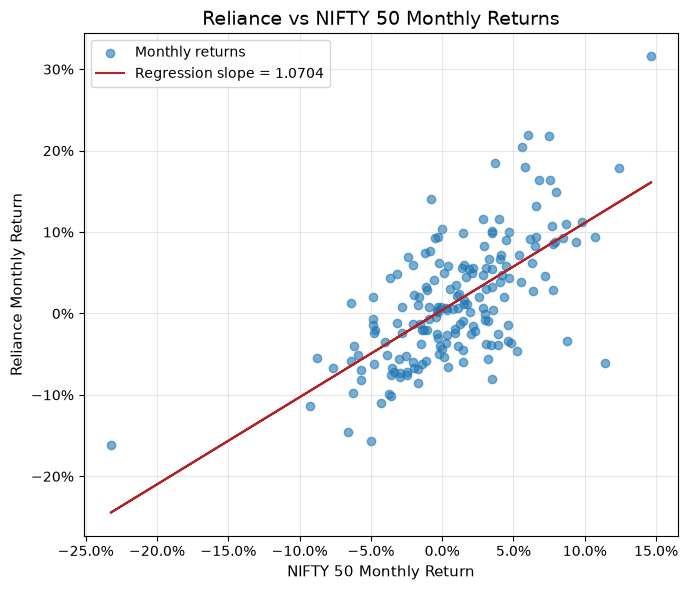

Regression slope   : 1.0704
Covariance-based beta: 1.0704   <- both estimates of beta agree, as expected


In [18]:
x = combined["Market_Return"]
y = combined["Monthly_Return"]
slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Monthly returns")
plt.plot(x, slope * x + intercept, color="firebrick",
         label=f"Regression slope = {slope:.4f}")
plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.xlabel("NIFTY 50 Monthly Return")
plt.ylabel("Reliance Monthly Return")
plt.title("Reliance vs NIFTY 50 Monthly Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/07_beta_scatter.png", dpi=150)
plt.show()

print(f"Regression slope   : {slope:.4f}")
print(f"Covariance-based beta: {beta:.4f}   <- both estimates of beta agree, as expected")

## 15. Key Findings

### 15.1 Return Profile
- **Average monthly return:** ~1.47%
- **CAGR:** ~15.28% per year over ~14.92 years
- **Cumulative return:** ~734.31% over the full period
- **Best / worst month:** April 2020 (COVID rebound,+31.63%) / March 2020 (COVID crash,-16.17%)

### 15.2 Risk Profile
- **Monthly volatility:** ~7.56%
- **Annualized volatility:** ~26.19%
- **Maximum drawdown:** ~-33.34% 
- **Distribution:** positively skewed(0.67) with fat tails relative to a normal distribution

### 15.3 Market Relationship
- **Correlation with NIFTY 50:** ~0.66
- **Beta relative to NIFTY 50:** ~1.07 (cross-validated two independent ways)

### 15.4 Overall Profile

Reliance delivered a 15.28% CAGR and 734.31% cumulative return over the sample, with an average monthly return of 1.47%. This performance came with 26.19% annualized volatility and a maximum drawdown of −33.34%, indicating substantial fluctuations and downside risk. A beta of 1.07 shows that Reliance historically moved slightly more than the NIFTY 50, while its 0.66 correlation indicates a meaningful but not complete relationship with the broader market. The return distribution was positively skewed with fat tails relative to a normal distribution, reflecting a tendency toward larger positive returns alongside greater-than-normal extreme movements.

> These are historical observations over one specific sample period and are not a forecast.


## 16. Limitations

Stated explicitly, rather than only implied:

- **No risk-free rate.** Sharpe/Sortino ratios are not computed because no risk-free-rate assumption is defended here. A future version could use the prevailing Indian 10-year G-Sec yield.
- **Dividend adjustment unverifiable.** `auto_adjust=True` adjusts for splits/bonus issues (verified in Section 6); whether dividends are included cannot be confirmed from the data alone.
- **Single stock, single benchmark.** No sector or peer comparison, no diversification effects.


## 17. Conclusion

This project evaluated the historical risk and return characteristics of Reliance Industries using ~15 years of
monthly data, progressing from price → returns → compounded performance (including CAGR) → volatility and
maximum drawdown → return distribution → market-relative measures (beta, correlation) against the NIFTY 50.

The framework distinguishes several concepts that are frequently conflated:

- **Return** measures periodic performance; **CAGR** measures compounded annualized performance — these are not the same number.
- **Volatility** measures total return dispersion; **maximum drawdown** measures the worst realized peak-to-trough loss — these answer different risk questions.
- **Correlation** measures co-movement strength; **beta** measures sensitivity — related but distinct.

$$\boxed{\text{Performance (Return, CAGR)} \rightarrow \text{Risk (Volatility, Drawdown)} \rightarrow \text{Market Relationship (Beta, Correlation)}}$$

Natural extensions (deliberately out of scope here — see Section 16): Sharpe/Sortino ratio with a defended
risk-free rate, rolling beta/volatility, and multi-stock or sector comparison.

> **Disclaimer:** This project is an educational, historical, quantitative analysis. It does not constitute investment advice or a recommendation to buy or sell any security.
